## 0. Imports

In [1]:
%load_ext autoreload
%autoreload 2


In [2]:
FLP_SERVICE = "health"  # сервис для оптимизации


In [3]:
# """Installs"""

# !pip install nc-time-axis
# !pip install netCDF4 h5netcdf
# !pip install xarray
# !pip install cdsapi
# !pip install networkx geopandas osmnx igraph matplotlib
# !pip install pysal scikit-learn libpysal tobler geopandas numpy pandas networkx
# !pip install access
# !pip install transliterate


In [4]:
"""Path handling"""

from pathlib import Path
import sys


# Ноутбук лежит в корне проекта, скрипты — в arctic_access/
module_path = str(Path.cwd() / "arctic_access")
if module_path not in sys.path:
    sys.path.insert(0, module_path)

# Патчим data_path в модулях, которые импортируют его напрямую (from ... import data_path).
# Делаем это после добавления пути в sys.path, но до первого использования.
_data_path = str(Path.cwd() / "arctic_access" / "data" / "processed") + "/"

import scripts.preprocesser.constants as _constants

_constants.data_path = _data_path

# huston импортирует data_path как локальную переменную — патчим и там
import scripts.preprocesser.huston as _huston

_huston.data_path = _data_path


In [5]:
"""Imports"""

import matplotlib.pyplot as plt
from tqdm import tqdm
import time

from scripts.calculator.calculator_this_pipeline import make_block_scheme
from scripts.plotter.plotter_transport_mode_prob import (
    plot_transport_probability_legacy,
)
from scripts.calculator.calculator_transport_prob import get_transport_probability
from scripts.preprocesser.preprocesser import get_data
from scripts.preprocesser.gcreator import make_g, add_temp_to_g
from scripts.preprocesser.huston import call_nasa
from scripts.calculator.calculator_stat import create_agglomeration_network
from scripts.calculator.calculator_monthly_mode import create_df_modes_monthly_fixed
import scripts.model.provision as provision
from scripts.plotter.plotter_multilayer_service_network import plot_multilayer_network
from scripts.plotter.plotter_flow_sankey import create_clean_sankey
from scripts.plotter.plotter_circular_network_sankey_style import (
    plot_circular_network_sankey_style,
)
from scripts.plotter.plotter_multi_temporal_nx_plots import (
    plot_temporal_service_evolution,
    calculate_temporal_metrics,
    plot_temporal_metrics,
)
from scripts.preprocesser.constants import (
    START_YEAR,
    MONTHS_IN_YEAR,
    CONST_BASE_DEMAND,
    transport_modes,
    transport_modes_color,
    service_radius_minutes,
    transport_mode_name_mapper,
    service_list,
    threshold,
    month_order,
)


tqdm.pandas()


## 1. Transport prob chart [user-defined]

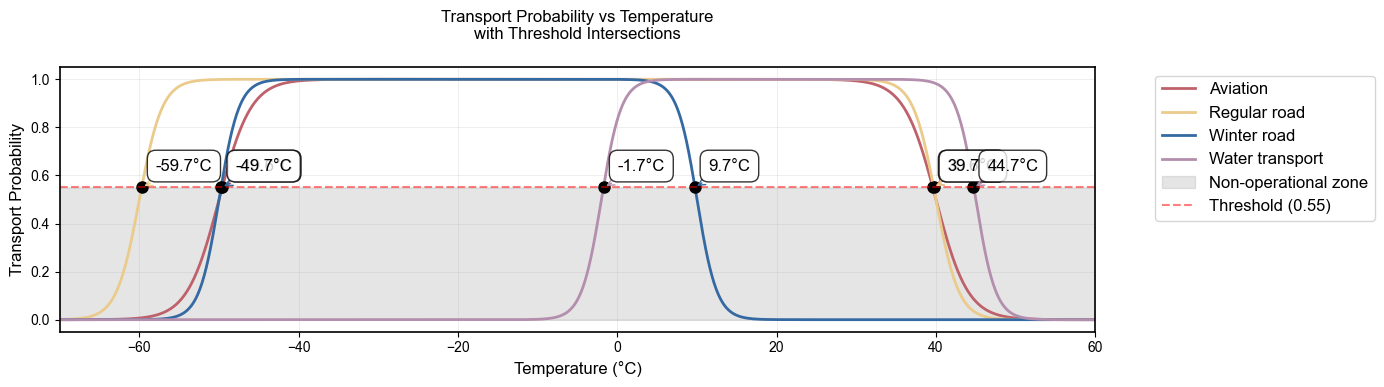

In [6]:
threshold_temperatures = plot_transport_probability_legacy(
    transport_modes,
    transport_modes_color,
    get_transport_probability,
    threshold,
    temps=None,
    font_size=12,
)


## 2. Main calculations

In [7]:
# Store results for each settlement and service
all_results = {}
# yakut_chuk
# yanao_kras
# mezen
# nao

data_path = "./arctic_access/data/"
settl_name_lst = ["yanao_kras"]
range_months = range(12)  # Starting Jan 1982

for SETTL_NAME in settl_name_lst:
    print("=" * 10, SETTL_NAME, "=" * 10)

    # Initialize settlement results
    all_results[SETTL_NAME] = {}
    service_list = [FLP_SERVICE]
    for SERVICE_NAME in service_list:
        print(" " * 10, SERVICE_NAME, " " * 10)

        CLIMATE_DATA_FILE_NAME = f"df_climate_{SETTL_NAME}.csv"

        settl, df_service, transport_df, infr_df = get_data(
            data_path,
            SETTL_NAME,
            transport_mode_name_mapper,
            transport_modes,
            SERVICE_NAME,
        )
        blocks_gdf = make_block_scheme(settl, df_service, service_name=SERVICE_NAME)
        G_undirected = make_g(transport_df, transport_modes, blocks_gdf, settl)

        df_monthly_list = call_nasa(blocks_gdf, CLIMATE_DATA_FILE_NAME)
        G_undirected = add_temp_to_g(G_undirected, df_monthly_list)

        net = create_agglomeration_network(
            graph=G_undirected,
            threshold=threshold,
            probability_function=get_transport_probability,
            provision_calculator=provision.calculate_graph_provision,
        )

        net.run_all_steps(
            range_months,
            service_radius_minutes=service_radius_minutes[SETTL_NAME],
            base_demand=CONST_BASE_DEMAND,
            service_name=SERVICE_NAME,
            return_assignment=True,
        )

        # Store results for this service
        all_results[SETTL_NAME][SERVICE_NAME] = {
            "net": net,
            "stats": net.stats,
            "graphs": net.stats.graphs,
            "records": net.stats.records,
            "results": net.stats.results,
            "G_undirected": G_undirected,
        }

        # Предполагаем что индекс df_stats — это месяцы в виде `i` (0...len-1)
        df_stats = net.stats.records
        try:
            df_stats["Month"] = df_stats.index % MONTHS_IN_YEAR + 1
            df_stats["Year"] = START_YEAR + df_stats.index // MONTHS_IN_YEAR
        except Exception:
            pass

        df_modes_monthly = create_df_modes_monthly_fixed(
            G_undirected,
            transport_modes,
            threshold_temperatures,
            START_YEAR,
            MONTHS_IN_YEAR=MONTHS_IN_YEAR,
        )

        # Store df_modes_monthly as well
        all_results[SETTL_NAME][SERVICE_NAME]["df_modes_monthly"] = df_modes_monthly


========== yanao_kras ==========
           health           


Running network analysis: 100%|██████████| 12/12 [00:01<00:00,  9.23it/s]


In [8]:
"""UPDATE: AFTER SOLVER"""


'UPDATE: AFTER SOLVER'

In [10]:
blocks_gdf


,id,name,geometry,population,epsg,capacity_health
0,0,Antipajuta,"POLYGON ((8557833.871 10781168.572, 8557829.05...",2685,3857,1200
1,1,Bajkalovsk,"POLYGON ((9309922.9 11299045.727, 9309918.085 ...",122,3857,600
2,2,Volochanka,"POLYGON ((10525085.939 11394394.768, 10525081....",530,3857,600
3,3,Vorontsovo,"POLYGON ((9302678.462 11645073.449, 9302673.64...",253,3857,600
4,4,Gaz-Sale,"POLYGON ((8794331.873 10260525.115, 8794327.05...",1735,3857,1200
5,5,Gyda,"POLYGON ((8738088.346 11365649.121, 8738083.53...",3614,3857,1200
6,6,Dikson,"POLYGON ((8964755.824 12319938.753, 8964751.00...",676,3857,600
7,7,Dudinka,"POLYGON ((9593965.134 10878102.764, 9593960.31...",19309,3857,9654
8,8,Zhdaniha,"POLYGON ((11452144.083 11815063.277, 11452139....",205,3857,600
9,9,Kazantsevo,"POLYGON ((9326378.57 11016198.616, 9326373.755...",17,3857,0


## 3. Multilayer chart

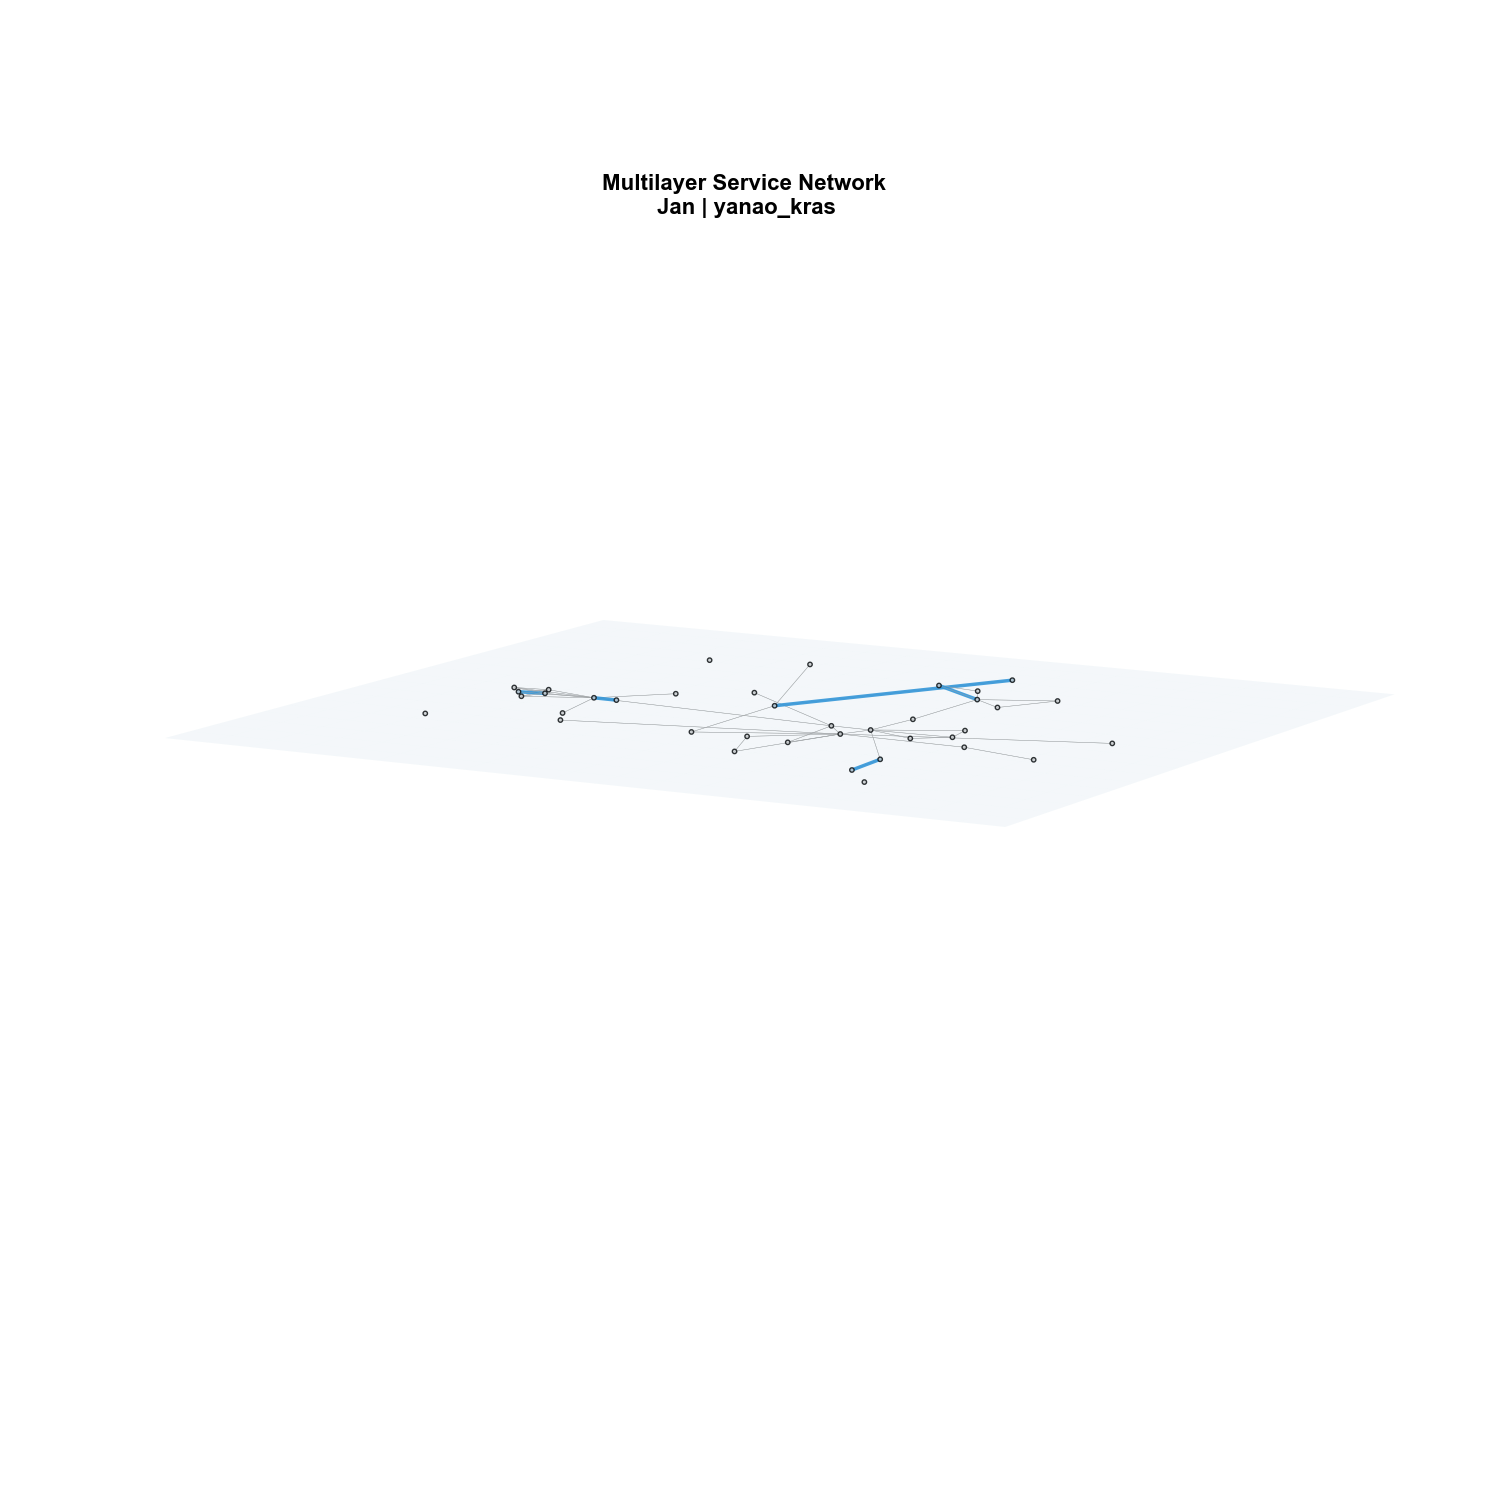

In [43]:
month = 0

# Example usage:
fig = plot_multilayer_network(
    all_results, SETTL_NAME, service_list, month=month, figsize=(15, 30)
)


# time.sleep(2)  # Pause to ensure the plot is rendered before saving
# plt.savefig(
#     f"../plots/multilayer_network_{SETTL_NAME}_{month_order[month]}.png",
#     bbox_inches="tight",
#     dpi=300,
# )


## 4. Sankey chart

In [44]:
# for service in service_list:
for service in [FLP_SERVICE]:
    month_start = 0
    end_month = 10
    graphs = all_results[SETTL_NAME][service]["stats"].graphs[month_start:end_month]
    _ = create_clean_sankey(graphs, service_name=service, month_start=month_start)


Creating Sankey for 10 time periods...
Excluding 30 self-sufficient settlements: ['Dikson', "Krasnosel'kup", "Noril'sk", 'Nosok', 'Dudinka', "Ust'-Port", 'Tuhard', 'Volochanka', 'Vorontsovo', 'Potapovo', 'Novaja', 'Gyda', "Ust'-Avam", 'Katyryk', 'Ratta', 'Bajkalovsk', 'Tarko-Sale', 'Tazovskij', 'Heta', 'Hantajskoe Ozero', 'Zhdaniha', 'Antipajuta', 'Kresty', 'Gaz-Sale', 'Novyj Urengoj', "Tol'ka", 'Karaul', 'Popigaj', 'Hatanga', 'Nahodka']
Found 8 consumers
T1: 5 assignments, 3 no provider
T2: 5 assignments, 3 no provider
T3: 5 assignments, 3 no provider
T4: 5 assignments, 3 no provider
T5: 5 assignments, 3 no provider
T6: 8 assignments, 0 no provider
T7: 8 assignments, 0 no provider
T8: 8 assignments, 0 no provider
T9: 8 assignments, 0 no provider
T10: 5 assignments, 3 no provider
Created 72 nodes
Created 80 flows


## 5. Circular flow chart

In [45]:
month_n = 0
# for service in service_list:
for service in [FLP_SERVICE]:
    # graphs = all_results[SETTL_NAME][service]["stats"].graphs[month_start:end_month]
    graphs = all_results[SETTL_NAME][service]["stats"].graphs[month_n : month_n + 1]
    for i, g in enumerate(graphs):
        fig = plot_circular_network_sankey_style(
            g,
            service_name=service,
            month_name=month_order[month_start + i],
        )
        fig.show()


## 6. Service coverage map

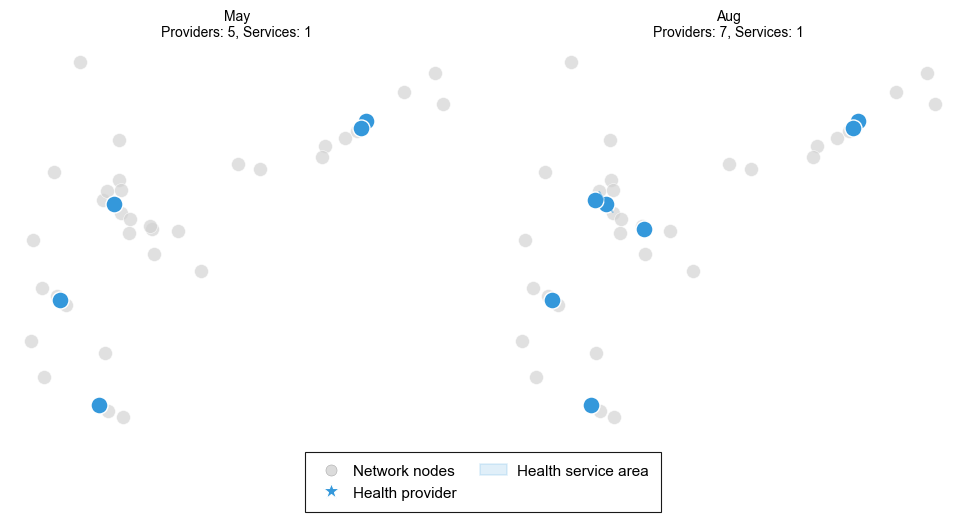

In [37]:
MONTH_RANGE = range(4, 8, 3)  # May to October (indices 4-9)
results = plot_temporal_service_evolution(all_results, SETTL_NAME, MONTH_RANGE)


## 8. Solver FLP — размещение новых объектов

In [15]:
"""Импорт солвера FLP"""

solver_path = str(Path.cwd() / "solver_flp" / "src")
if solver_path not in sys.path:
    sys.path.insert(0, solver_path)

from method import genetic_algorithm_main, choose_edges, block_coverage, fitness_plot


In [16]:
"""Параметры солвера"""

FLP_MONTH = 0  # месяц (индекс), для которого берём снапшот обеспеченности

# Параметры генетического алгоритма
SERVICE_RADIUS = service_radius_minutes[SETTL_NAME]

# Параметры генетического алгоритма
population_size = 50
num_generations = 20
num_parents = 10
num_offspring = population_size - num_parents
mutation_rate = 0.7


In [17]:
"""Подготовка данных: извлекаем provision-результат за выбранный месяц"""

import geopandas as gpd
import pandas as pd
import numpy as np

# Граф за нужный месяц
G_month = all_results[SETTL_NAME][FLP_SERVICE]["stats"].graphs[FLP_MONTH]

# Собираем df_with_demand из атрибутов узлов
node_records = []
for node, data in G_month.nodes(data=True):
    node_records.append(
        {
            "id": node,
            "name": data.get("name", node),
            "population": data.get("population", 0),
            "demand": data.get("demand", 0),
            "demand_within": data.get("demand_within", 0),
            "demand_without": data.get("demand_without", 0),
            f"capacity_{FLP_SERVICE}": data.get(f"capacity_{FLP_SERVICE}", 0),
            "capacity_left": data.get("capacity_left", 0),
            "provision": data.get("provision", 0),
            "geometry": data.get("geometry", None),
        }
    )

df_with_demand = gpd.GeoDataFrame(node_records).set_index("id")
if df_with_demand.geometry.notna().any():
    df_with_demand = df_with_demand.set_geometry("geometry")

print(f"Всего узлов: {len(df_with_demand)}")
print(f"Не обеспечены (provision < 1): {(df_with_demand['provision'] < 1).sum()}")
df_with_demand[df_with_demand["provision"] < 1]


Всего узлов: 38
Не обеспечены (provision < 1): 7


,name,population,demand,demand_within,demand_without,capacity_health,capacity_left,provision,geometry
id,,,,,,,,,
Kazantsevo,Kazantsevo,17,3.0,0.0,0.0,0,0.0,0.0,"POLYGON ((9326378.57 11016198.616, 9326373.755..."
Munguj,Munguj,11,2.0,0.0,0.0,0,0.0,0.0,"POLYGON ((9325777.813 11211069.287, 9325772.99..."
Polikarpovsk,Polikarpovsk,33,4.0,0.0,4.0,0,0.0,0.0,"POLYGON ((9203863.901 11202137.635, 9203859.08..."
Levinskie Peski,Levinskie Peski,116,14.0,0.0,0.0,0,0.0,0.0,"POLYGON ((9575298.303 10898352.105, 9575293.48..."
Novorybnaja,Novorybnaja,556,67.0,0.0,67.0,0,0.0,0.0,"POLYGON ((11778111.452 12060797.181, 11778106...."
Kikkiakki,Kikkiakki,30,4.0,0.0,4.0,0,0.0,0.0,"POLYGON ((9214638.771 9296960.144, 9214633.955..."
Syndassko,Syndassko,496,60.0,0.0,60.0,0,0.0,0.0,"POLYGON ((12047492.274 12225283.315, 12047487...."


In [18]:
"""Строим матрицу доступности из графа (кратчайшие пути)"""

from scripts.model.provision import create_adjacency_matrix

adj_matrix = create_adjacency_matrix(G_month)

# Оставляем только необеспеченные узлы
uncovered = df_with_demand.copy()
uncovered_ids = uncovered.index.tolist()

acc_matrix_uncovered = adj_matrix.loc[uncovered_ids, uncovered_ids].copy()
acc_matrix_uncovered.reset_index(drop=True, inplace=True)
acc_matrix_uncovered.columns = acc_matrix_uncovered.index

uncovered.reset_index(drop=True, inplace=True)

print(f"Необеспеченных блоков: {len(uncovered)}")


Необеспеченных блоков: 38


In [19]:
uncovered.rename(columns={f"capacity_{FLP_SERVICE}": "capacity"}, inplace=True)


In [20]:
"""
НИЖЕ НУЖНО ОТДАВАТЬ ПОЛНЫЙ ГДФ (который выше)
"""


'\nНИЖЕ НУЖНО ОТДАВАТЬ ПОЛНЫЙ ГДФ (который выше)\n'

In [46]:
"""Запуск генетического алгоритма"""

edges_uncovered = choose_edges(
    sim_matrix=acc_matrix_uncovered, service_radius=SERVICE_RADIUS
)
print(f"Рёбер в графе кандидатов: {len(edges_uncovered)}")

best_candidate, fitness_history = genetic_algorithm_main(
    matrix=acc_matrix_uncovered,
    edges=edges_uncovered,
    population_size=population_size,
    num_generations=num_generations,
    df=uncovered,
    service_radius=SERVICE_RADIUS,
    mutation_rate=mutation_rate,
    num_parents=num_parents,
    num_offspring=num_offspring,
    number_res="all",
)

fitness_plot(fitness_history)


100%|██████████| 38/38 [00:00<00:00, 760.67it/s]


Рёбер в графе кандидатов: 43


 20%|██        | 4/20 [00:12<00:50,  3.17s/it]


KeyboardInterrupt: 

In [22]:
from method import (
    genetic_algorithm_main,
    choose_edges,
    fitness_plot,
    block_coverage,
    services_plot,
    connect_blocks_plot,
)


In [23]:
"""Результаты: новые объекты и зоны обслуживания"""

capacities, res_id = block_coverage(
    best_candidate, SERVICE_RADIUS, uncovered, uncovered_ids
)

print("Вместимости новых объектов:", [c for c in capacities if c and c > 0])
print("\nПривязка блоков к новым объектам (id_объекта -> [id_блоков]):")
res_id


Вместимости новых объектов: [50.0, 67.0, 50.0, 60.0]

Привязка блоков к новым объектам (id_объекта -> [id_блоков]):


{'Karaul': ['Bajkalovsk',
  'Vorontsovo',
  'Dudinka',
  'Karaul',
  'Nosok',
  'Volochanka',
  'Tuhard',
  "Ust'-Port",
  'Hantajskoe Ozero',
  'Polikarpovsk',
  'Potapovo'],
 'Novorybnaja': ['Novorybnaja'],
 "Tol'ka": ["Krasnosel'kup",
  'Tarko-Sale',
  'Kikkiakki',
  'Novyj Urengoj',
  "Tol'ka"],
 'Syndassko': ['Syndassko']}

In [24]:
res_id.keys()


dict_keys(['Karaul', 'Novorybnaja', "Tol'ka", 'Syndassko'])

In [26]:
selected_potential_services = gpd.GeoDataFrame(df_with_demand.loc[:, "geometry"]).loc[
    list(res_id.keys()), :
]
selected_potential_services[f"capacity_{FLP_SERVICE}"] = [
    capacity for capacity in capacities if capacity > 0
]

arr_index = np.intersect1d(
    selected_potential_services.index,
    df_with_demand[df_with_demand[f"capacity_{FLP_SERVICE}"] > 0].index,
)

for i in arr_index:
    selected_potential_services.loc[i, f"capacity_{FLP_SERVICE}"] += df_with_demand.loc[
        i, f"capacity_{FLP_SERVICE}"
    ]

df_opt = (
    df_with_demand.set_crs(3857)
    .sjoin(selected_potential_services.set_crs(3857), how="left", lsuffix="osn")
    .fillna(0)
)
df_opt["capacity"] = (
    df_opt[f"capacity_{FLP_SERVICE}_osn"] + df_opt[f"capacity_{FLP_SERVICE}_right"]
)
df_opt.drop(
    columns=[f"capacity_{FLP_SERVICE}_osn", "id_right", f"capacity_{FLP_SERVICE}_right"],
    inplace=True,
)


In [27]:
uncovered_demand = df_with_demand[df_with_demand["provision"] < 1]
accessibility_matrix_uncovered_demand = acc_matrix_uncovered
id_matrix = accessibility_matrix_uncovered_demand.index.tolist()

uncovered_demand.reset_index(drop=True, inplace=True)
accessibility_matrix_uncovered_demand.reset_index(drop=True, inplace=True)
accessibility_matrix_uncovered_demand.columns = (
    accessibility_matrix_uncovered_demand.index
)


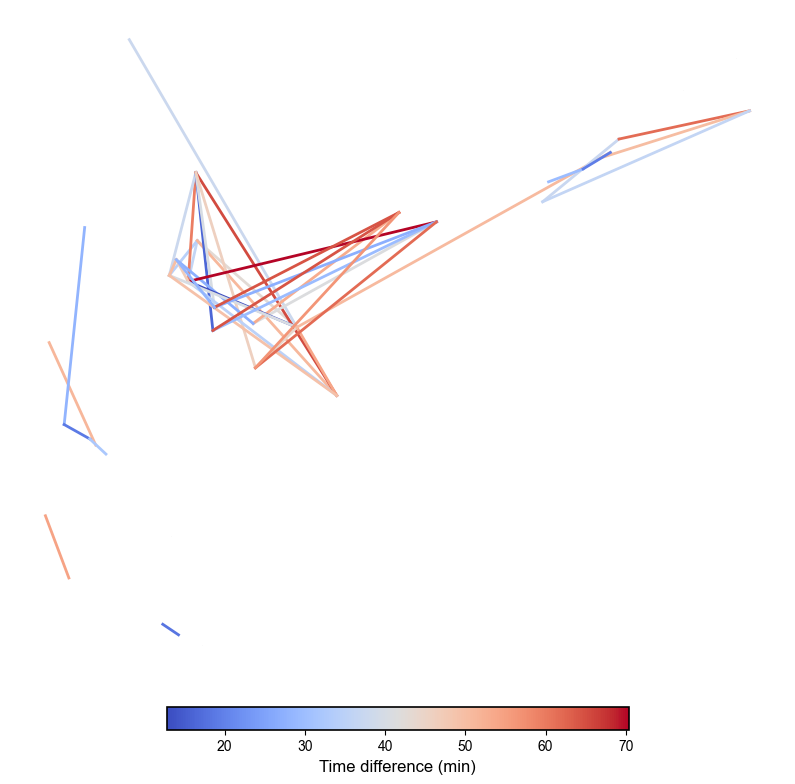

In [28]:
connect_blocks_plot(
    id_matrix, accessibility_matrix_uncovered_demand, df_opt, best_candidate
)


## 9. Применение рекомендаций по связности и пересчёт

In [38]:
"""Применяем результаты солвера FLP: добавляем новые объекты в blocks_gdf"""

# res_id: {имя_узла: [обслуживаемые блоки]}, capacities: [вместимости]
new_capacities = [c for c in capacities if c and c > 0]
for facility_name, capacity in zip(res_id.keys(), new_capacities):
    mask = blocks_gdf["name"] == facility_name
    blocks_gdf.loc[mask, f"capacity_{FLP_SERVICE}"] += capacity
    print(f"  {facility_name}: +{capacity:.0f} capacity")

print("blocks_gdf обновлён. Новые вместимости:")
blocks_gdf[blocks_gdf["name"].isin(list(res_id.keys()))][["name", f"capacity_{FLP_SERVICE}"]]


  Karaul: +50 capacity
  Novorybnaja: +67 capacity
  Tol'ka: +50 capacity
  Syndassko: +60 capacity
blocks_gdf обновлён. Новые вместимости:


,name,capacity_health
10,Karaul,1250
19,Novorybnaja,67
27,Syndassko,60
31,Tol'ka,1250


In [39]:
"""Применяем улучшенные времена из best_candidate к графу G_undirected"""

import copy

# best_candidate — DataFrame с числовыми индексами 0..N-1 (соответствуют uncovered_ids)
# uncovered_ids — список имён узлов в том же порядке
# Сравниваем с исходной матрицей acc_matrix_uncovered, находим изменившиеся рёбра

improved_edges = []
for num_i, name_i in enumerate(uncovered_ids):
    for num_j, name_j in enumerate(uncovered_ids):
        if num_i >= num_j:
            continue
        orig = acc_matrix_uncovered.loc[num_i, num_j]
        new_val = best_candidate.loc[num_i, num_j]
        if abs(orig - new_val) > 1e-6 and orig < float('inf'):
            improved_edges.append((name_i, name_j, orig, new_val))

print(f"Рёбер с улучшенными временами: {len(improved_edges)}")
for u, v, old_t, new_t in improved_edges:
    print(f"  {u} ↔ {v}: {old_t:.1f} → {new_t:.1f} мин (−{(1 - new_t/old_t)*100:.0f}%)")


Рёбер с улучшенными временами: 43
  Antipajuta ↔ Gaz-Sale: 126.0 → 74.6 мин (−41%)
  Gyda ↔ Nahodka: 125.0 → 97.1 мин (−22%)
  Nahodka ↔ Tazovskij: 135.0 → 116.1 мин (−14%)
  Bajkalovsk ↔ Karaul: 93.0 → 56.7 мин (−39%)
  Bajkalovsk ↔ Noril'sk: 120.0 → 77.3 мин (−36%)
  Bajkalovsk ↔ Nosok: 103.0 → 68.6 мин (−33%)
  Bajkalovsk ↔ Hantajskoe Ozero: 113.0 → 61.9 мин (−45%)
  Vorontsovo ↔ Karaul: 127.0 → 67.2 мин (−47%)
  Vorontsovo ↔ Nosok: 137.0 → 99.1 мин (−28%)
  Vorontsovo ↔ Tuhard: 108.0 → 91.8 мин (−15%)
  Vorontsovo ↔ Ust'-Port: 108.0 → 67.6 мин (−37%)
  Vorontsovo ↔ Hantajskoe Ozero: 147.0 → 81.7 мин (−44%)
  Vorontsovo ↔ Potapovo: 111.0 → 65.0 мин (−41%)
  Tibej-Sale ↔ Tazovskij: 109.0 → 76.8 мин (−30%)
  Dikson ↔ Noril'sk: 110.0 → 72.1 мин (−34%)
  Dudinka ↔ Volochanka: 109.0 → 67.7 мин (−38%)
  Dudinka ↔ Ust'-Avam: 120.0 → 67.0 мин (−44%)
  Dudinka ↔ Polikarpovsk: 143.0 → 116.0 мин (−19%)
  Karaul ↔ Noril'sk: 109.0 → 96.3 мин (−12%)
  Karaul ↔ Volochanka: 150.0 → 76.7 мин (−49%)


/var/folders/jn/d6x3c7jd7594dtldxq22ysn80000gn/T/ipykernel_57147/1815508703.py:16: RuntimeWarning:

invalid value encountered in scalar subtract



In [40]:
"""Обновляем веса рёбер в G_undirected и пересчитываем обеспеченность"""

G_improved = copy.deepcopy(G_undirected)

# Обновляем веса рёбер: для каждого улучшенного ребра меняем weight во всех параллельных рёбрах
for name_i, name_j, old_t, new_t in improved_edges:
    ratio = new_t / old_t
    if G_improved.has_edge(name_i, name_j):
        for key, data in G_improved[name_i][name_j].items():
            G_improved[name_i][name_j][key]['weight'] = round(data['weight'] * ratio, 2)
    if G_improved.has_edge(name_j, name_i):
        for key, data in G_improved[name_j][name_i].items():
            G_improved[name_j][name_i][key]['weight'] = round(data['weight'] * ratio, 2)

# Создаём новую агломерационную сеть с улучшенным графом
net_improved = create_agglomeration_network(
    graph=G_improved,
    threshold=threshold,
    probability_function=get_transport_probability,
    provision_calculator=provision.calculate_graph_provision,
)

net_improved.run_all_steps(
    range_months,
    service_radius_minutes=service_radius_minutes[SETTL_NAME],
    base_demand=CONST_BASE_DEMAND,
    service_name=FLP_SERVICE,
    return_assignment=True,
)

all_results[SETTL_NAME][f"{FLP_SERVICE}_improved"] = {
    "net": net_improved,
    "stats": net_improved.stats,
    "graphs": net_improved.stats.graphs,
    "records": net_improved.stats.records,
    "results": net_improved.stats.results,
    "G_undirected": G_improved,
}

print("Пересчёт завершён.")


Running network analysis: 100%|██████████| 12/12 [00:02<00:00,  5.27it/s]

Пересчёт завершён.


In [41]:
"""Сравнение обеспеченности: до и после улучшения связности"""

G_before = all_results[SETTL_NAME][FLP_SERVICE]['stats'].graphs[FLP_MONTH]
G_after = all_results[SETTL_NAME][f"{FLP_SERVICE}_improved"]['stats'].graphs[FLP_MONTH]

records_before, records_after = [], []
for node, data in G_before.nodes(data=True):
    records_before.append({'name': node, 'provision_before': data.get('provision', 0)})
for node, data in G_after.nodes(data=True):
    records_after.append({'name': node, 'provision_after': data.get('provision', 0)})

import pandas as pd
df_before = pd.DataFrame(records_before).set_index('name')
df_after = pd.DataFrame(records_after).set_index('name')
df_compare = df_before.join(df_after)
df_compare['delta'] = df_compare['provision_after'] - df_compare['provision_before']
df_compare = df_compare.sort_values('delta', ascending=False)

print('Изменение обеспеченности после улучшения связности:')
df_compare[df_compare['delta'] != 0]


Изменение обеспеченности после улучшения связности:


,provision_before,provision_after,delta
name,,,


In [42]:
# Подменяем результаты на improved-версию — после этого секции 3–6 можно запустить повторно
all_results[SETTL_NAME][FLP_SERVICE] = all_results[SETTL_NAME][f"{FLP_SERVICE}_improved"]
net = net_improved
G_undirected = G_improved
print("Активна improved-версия. Перезапусти секции 3–6.")


Активна improved-версия. Перезапусти секции 3–6.
